# Server Test Notebook

In [7]:
import json
import pandas as pd
import requests
import base64
from PIL import Image
import io

test_raw = pd.read_csv('data/GUIDE_Test.csv', nrows=10000)

server_cols = [
    'IncidentId', 'OrgId', 'Timestamp', 'DetectorId', 'AlertTitle',
    'Category', 'MitreTechniques', 'EntityType', 'EvidenceRole',
    'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
    'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
    'EmailClusterId', 'RegistryKey', 'RegistryValueName', 'RegistryValueData',
    'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'ThreatFamily',
    'FileName', 'FolderPath', 'ResourceIdName', 'ResourceType', 'Roles',
    'OSFamily', 'OSVersion', 'AntispamDirection', 'SuspicionLevel',
    'LastVerdict', 'CountryCode', 'State', 'City', 'AlertId',
    'ActionGrouped', 'ActionGranular'
]

sample_id = test_raw['IncidentId'].iloc[5]
incident_rows = test_raw[test_raw['IncidentId'] == sample_id]

print(f"IncidentId : {sample_id}")
print(f"Evidence rows : {len(incident_rows)}")

payload = json.loads(incident_rows[server_cols].to_json(orient='records'))
print(f"Payload rows  : {len(payload)}")

IncidentId : 238
Evidence rows : 23
Payload rows  : 23


In [8]:
pd.set_option('display.max_columns', None)
incident_rows

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,ActionGrouped,ActionGranular,EntityType,EvidenceRole,DeviceId,Sha256,IpAddress,Url,AccountSid,AccountUpn,AccountObjectId,AccountName,DeviceName,NetworkMessageId,EmailClusterId,RegistryKey,RegistryValueName,RegistryValueData,ApplicationId,ApplicationName,OAuthApplicationId,ThreatFamily,FileName,FolderPath,ResourceIdName,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City,Usage
5,670014899930,0,238,378946,2024-06-06T08:10:50.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,2544,3392,2558,2696,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
1227,670014899930,0,238,376727,2024-06-06T00:48:32.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,Ip,Related,98799,138268,34,160396,441377,673934,425863,453297,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,1,0,0,Public
1367,670014899930,0,238,370542,2024-06-05T22:50:46.000Z,4,3,InitialAccess,NaN,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,682,908,676,725,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
1379,670014899930,0,238,162580,2024-06-06T02:38:38.000Z,7,6,InitialAccess,NaN,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,779,1048,772,830,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
2153,670014899930,0,238,175146,2024-06-06T06:10:18.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,163,233,155,186,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
2539,670014899930,0,238,372628,2024-06-05T19:00:32.000Z,4,3,InitialAccess,NaN,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,2347,3109,2357,2486,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
2558,670014899930,0,238,108283,2024-06-05T21:10:39.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,1980,2639,1974,2089,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
2826,670014899930,0,238,382502,2024-06-06T09:54:22.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,939,1310,940,1005,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
3039,670014899930,0,238,411069,2024-06-05T22:22:35.000Z,4,3,InitialAccess,NaN,TruePositive,NaN,NaN,Ip,Related,98799,138268,5,160396,441377,673934,425863,453297,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,0,16,17,Public
3147,670014899930,0,238,520650,2024-06-06T09:35:09.000Z,0,0,InitialAccess,T1078;T1078.004,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,3155,4251,3169,3354,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public


## /health — check server is running

In [9]:
r = requests.get("http://localhost:8000/health")
r.json()

{'status': 'ok',
 'device': 'cuda',
 'classes': ['BenignPositive', 'FalsePositive', 'TruePositive'],
 'num_features': 182,
 'best_val_f1': 0.9122007554888222,
 'test_f1': 0.9043692159515117,
 'llm_available': True}

## /predict — plain prediction

In [10]:
r = requests.post("http://localhost:8000/predict", json=payload)
result = r.json()
for res in result["results"]:
    print(f"Incident : {res['incident_id']}")
    print(f"Prediction : {res['prediction']}")
    print(f"Probabilities : {res['probabilities']}")

Incident : 238
Prediction : TruePositive
Probabilities : {'BenignPositive': 0.0118, 'FalsePositive': 0.0226, 'TruePositive': 0.9656}


## /predict/explain — prediction + waterfall plot

Prediction : TruePositive
Probabilities : {'BenignPositive': 0.0118, 'FalsePositive': 0.0226, 'TruePositive': 0.9656}


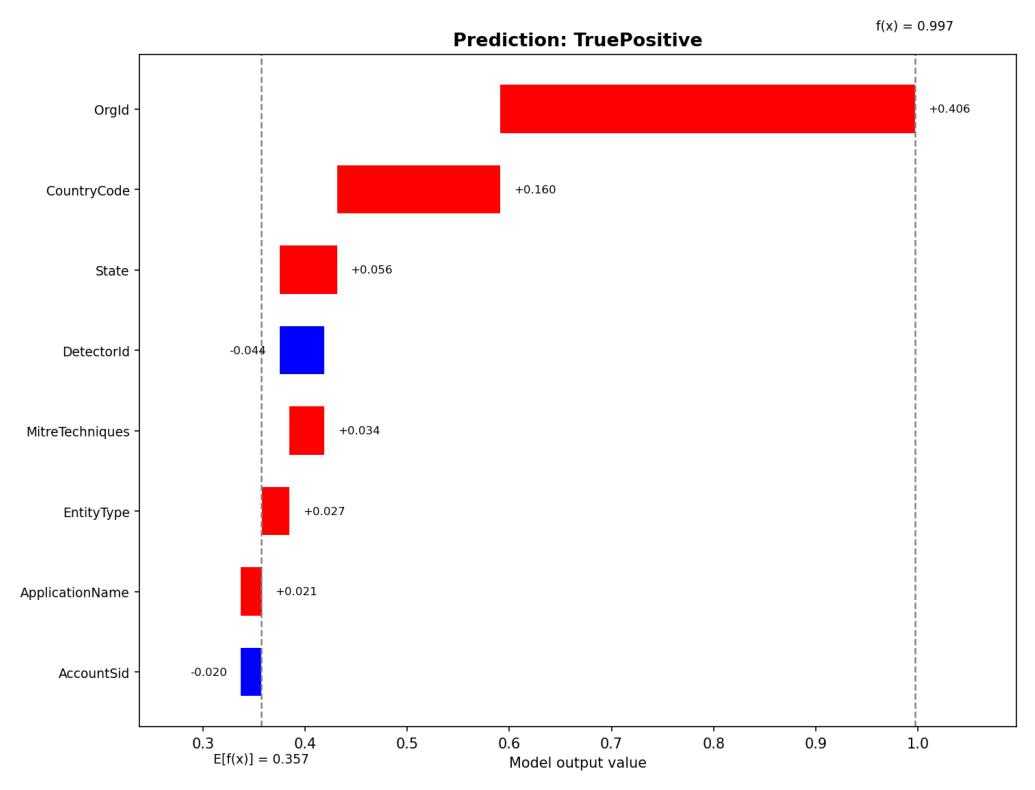

In [18]:
import matplotlib.pyplot as plt

r = requests.post("http://localhost:8000/predict/explain", json=payload)

if r.status_code == 200:
    result = r.json()["results"][0]
    print(f"Prediction : {result['prediction']}")
    print(f"Probabilities : {result['probabilities']}")

    # decode base64 PNG and display inline in the notebook
    img_bytes = base64.b64decode(result["waterfall_png_b64"])
    img = Image.open(io.BytesIO(img_bytes))

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig('server_test_waterfall_output.png', dpi=150)
    plt.show()
else:
    print(r.json())

## /predict/explain/text — prediction + waterfall + LLM explanation

Prediction : TruePositive
Probabilities : {'BenignPositive': 0.0118, 'FalsePositive': 0.0226, 'TruePositive': 0.9656}

************************************************************
LLM explaination output:
************************************************************
**Incident Analysis for ID 238**

The prediction indicates that this incident is likely a **TruePositive**, meaning it is a confirmed security threat with a high confidence level of 96.6%. The model predicts this with a 96.6% confidence, ruling out BenignPositive (1.2%) and FalsePositive (2.3%) possibilities.

The top 5 strongest reasons for this prediction are:

1. The organisation's historical rate of TruePositive incidents is 100%, indicating a high likelihood of this being a genuine threat.
2. The presence of 8 unique country codes suggests a potential global attack or command and control activity.
3. The absence of FalsePositive incidents in the organisation's history (0.0%) contributes to the prediction, as it reduces 

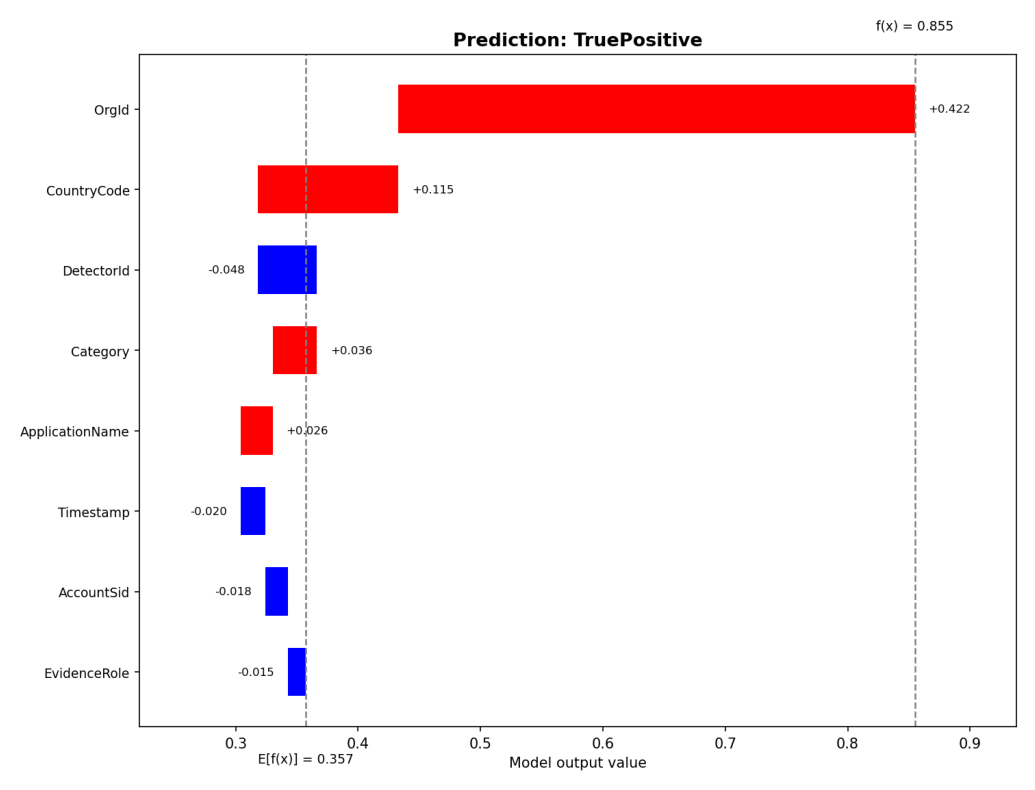

In [12]:
r = requests.post("http://localhost:8000/predict/explain/text", json=payload)

if r.status_code == 200:
    result = r.json()["results"][0]
    print(f"Prediction : {result['prediction']}")
    print(f"Probabilities : {result['probabilities']}")
    print()
    print("*" * 60)
    print("LLM explaination output:")
    print("*" * 60)
    print(result["explanation"])
    print()

    # show waterfall
    img_bytes = base64.b64decode(result["waterfall_png_b64"])
    img = Image.open(io.BytesIO(img_bytes))
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(r.json())

## Test multiple incidents at once

In [13]:
incident_ids = test_raw["IncidentId"].unique()[:3]
multi_rows = test_raw[test_raw["IncidentId"].isin(incident_ids)]
multi_payload = json.loads(multi_rows[server_cols].to_json(orient="records"))

print(f"Sending {len(multi_payload)} evidence rows across {len(incident_ids)} incidents")

r = requests.post("http://localhost:8000/predict", json=multi_payload)

if r.status_code == 200:
    for res in r.json()["results"]:
        print(f"  Incident {res['incident_id']} → {res['prediction']}  {res['probabilities']}")
else:
    print(r.json())

Sending 3 evidence rows across 3 incidents
  Incident 11767 → BenignPositive  {'BenignPositive': 0.7699, 'FalsePositive': 0.1011, 'TruePositive': 0.1291}
  Incident 32247 → BenignPositive  {'BenignPositive': 0.8178, 'FalsePositive': 0.0728, 'TruePositive': 0.1094}
  Incident 91158 → BenignPositive  {'BenignPositive': 0.8868, 'FalsePositive': 0.0491, 'TruePositive': 0.0642}
